## NYC complaints 311 Calls

In this notebook we will exploit Pandas to perform data analysis on a dataset of calls to 311 (municipal calls, not emergency) in the New York City area.

Download the data from [here](https://data.cityofnewyork.us/Social-Services/311-Service-Requests-from-2010-to-Present/erm2-nwe9) (11Gb+... Go to Export -> CSV).

Or [here](https://bit.ly/3kfv10H) (~500MB)

In [2]:
%matplotlib inline 
import pandas as pd
import matplotlib.pyplot as plt

plt.rcParams['figure.figsize'] = (15, 5)  # large and nice


In [3]:
complaints = pd.read_csv('/home/marco/Downloads/311/311_small.csv')

/home/marco/.local/lib/python3.8/site-packages/IPython/core/interactiveshell.py:3062: DtypeWarning: Columns (8,17,31,32,34,35,36,37) have mixed types.Specify dtype option on import or set low_memory=False.
  has_raised = await self.run_ast_nodes(code_ast.body, cell_name,


In [4]:
type(complaints)

pandas.core.frame.DataFrame

In [5]:
complaints.columns

Index(['Unique Key', 'Created Date', 'Closed Date', 'Agency', 'Agency Name',
       'Complaint Type', 'Descriptor', 'Location Type', 'Incident Zip',
       'Incident Address', 'Street Name', 'Cross Street 1', 'Cross Street 2',
       'Intersection Street 1', 'Intersection Street 2', 'Address Type',
       'City', 'Landmark', 'Facility Type', 'Status', 'Due Date',
       'Resolution Description', 'Resolution Action Updated Date',
       'Community Board', 'BBL', 'Borough', 'X Coordinate (State Plane)',
       'Y Coordinate (State Plane)', 'Open Data Channel Type',
       'Park Facility Name', 'Park Borough', 'Vehicle Type',
       'Taxi Company Borough', 'Taxi Pick Up Location', 'Bridge Highway Name',
       'Bridge Highway Direction', 'Road Ramp', 'Bridge Highway Segment',
       'Latitude', 'Longitude', 'Location'],
      dtype='object')

In [6]:
for pos, colname in enumerate(complaints.columns):
    print(pos, colname)

0 Unique Key
1 Created Date
2 Closed Date
3 Agency
4 Agency Name
5 Complaint Type
6 Descriptor
7 Location Type
8 Incident Zip
9 Incident Address
10 Street Name
11 Cross Street 1
12 Cross Street 2
13 Intersection Street 1
14 Intersection Street 2
15 Address Type
16 City
17 Landmark
18 Facility Type
19 Status
20 Due Date
21 Resolution Description
22 Resolution Action Updated Date
23 Community Board
24 BBL
25 Borough
26 X Coordinate (State Plane)
27 Y Coordinate (State Plane)
28 Open Data Channel Type
29 Park Facility Name
30 Park Borough
31 Vehicle Type
32 Taxi Company Borough
33 Taxi Pick Up Location
34 Bridge Highway Name
35 Bridge Highway Direction
36 Road Ramp
37 Bridge Highway Segment
38 Latitude
39 Longitude
40 Location


In [9]:
complaints.head(3)

,Unique Key,Created Date,Closed Date,Agency,Agency Name,Complaint Type,Descriptor,Location Type,Incident Zip,Incident Address,...,Vehicle Type,Taxi Company Borough,Taxi Pick Up Location,Bridge Highway Name,Bridge Highway Direction,Road Ramp,Bridge Highway Segment,Latitude,Longitude,Location
0,41698274,02/14/2019 11:02:22 AM,03/05/2019 09:02:11 AM,HPD,Department of Housing Preservation and Develop...,PLUMBING,BASIN/SINK,RESIDENTIAL BUILDING,10033,809 WEST 177 STREET,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,40.847999,-73.940296,"(40.8479991, -73.9402961)"
1,41698275,02/08/2019 06:49:38 AM,03/04/2019 02:46:11 PM,HPD,Department of Housing Preservation and Develop...,PLUMBING,BASIN/SINK,RESIDENTIAL BUILDING,11385,71-38 71 STREET,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,40.704184,-73.880987,"(40.7041837, -73.8809868)"
2,41698276,01/17/2019 12:35:37 PM,02/14/2019 08:52:02 AM,HPD,Department of Housing Preservation and Develop...,PLUMBING,BASIN/SINK,RESIDENTIAL BUILDING,10460,867 CROTONA PARK NORTH,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,40.839497,-73.889523,"(40.8394969, -73.8895232)"


In [10]:
complaints['Complaint Type'].unique()

array(['PLUMBING', 'Noise - Residential', 'Street Sign - Damaged',
       'Illegal Parking', 'General Construction/Plumbing', 'Traffic',
       'Dirty Conditions', 'Noise - Vehicle', 'Derelict Vehicles',
       'SAFETY', 'UNSANITARY CONDITION', 'Street Condition',
       'Food Poisoning', 'Blocked Driveway',
       'Special Projects Inspection Team (SPIT)', 'Sanitation Condition',
       'Missed Collection (All Materials)', 'Street Light Condition',
       'Consumer Complaint', 'WATER LEAK', 'Air Quality',
       'Traffic Signal Condition', 'Water System', 'Food Establishment',
       'DOOR/WINDOW', 'Sidewalk Condition', 'PAINT/PLASTER', 'ELECTRIC',
       'Taxi Report', 'APPLIANCE', 'For Hire Vehicle Report',
       'Taxpayer Advocate Inquiry', 'Bus Stop Shelter Complaint',
       'Homeless Person Assistance', 'Building/Use',
       'For Hire Vehicle Complaint', 'Other Enforcement', 'GENERAL',
       'ELEVATOR', 'Dead/Dying Tree', 'FLOORING/STAIRS', 'HEAT/HOT WATER',
       'Taxi Comp

In [11]:
complaints[['Complaint Type', 'Borough']][:10]

,Complaint Type,Borough
0,PLUMBING,MANHATTAN
1,PLUMBING,QUEENS
2,PLUMBING,BRONX
3,PLUMBING,MANHATTAN
4,PLUMBING,BROOKLYN
5,PLUMBING,BRONX
6,PLUMBING,QUEENS
7,PLUMBING,BROOKLYN
8,Noise - Residential,BROOKLYN
9,Street Sign - Damaged,STATEN ISLAND


In [12]:
len(complaints)

999999

In [13]:
complaints['Complaint Type'].value_counts()

Noise - Residential                    81373
Request Large Bulky Item Collection    69330
Illegal Parking                        63198
HEAT/HOT WATER                         57807
Blocked Driveway                       44623
                                       ...  
Misc. Comments';declare @q ...             1
Misc. Comments;declare @q v...             1
idexf3mrb7)(!(objectClass=*)               1
Misc. Comments'&quot;`0&amp...             1
*)(objectClass=*                           1
Name: Complaint Type, Length: 282, dtype: int64

In [14]:
# WARNING: HUGE MEMORY REQUIRED (ON THE BIG FILE)
complaints = complaints[~complaints['Complaint Type'].str.contains('Misc.')]

In [15]:
len(complaints)

985666

In [16]:
complaint_count = complaints['Complaint Type'].value_counts()

In [17]:
type(complaint_count)

pandas.core.series.Series

In [18]:
complaint_count.head()

Noise - Residential                    81373
Request Large Bulky Item Collection    69330
Illegal Parking                        63198
HEAT/HOT WATER                         57807
Blocked Driveway                       44623
Name: Complaint Type, dtype: int64

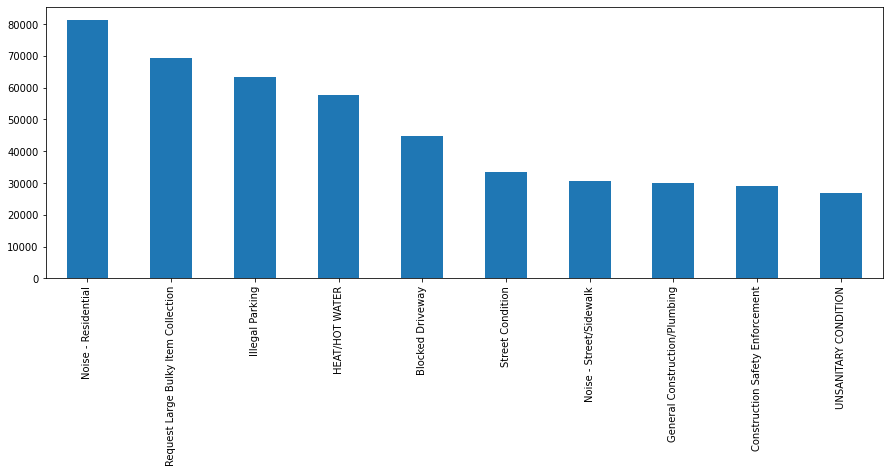

In [19]:
complaint_count[:10].plot(kind='bar')

In [20]:
noise_complaints = complaints[complaints['Complaint Type'] == 'Noise - Street/Sidewalk']

In [21]:
noise_complaints.head(3)

,Unique Key,Created Date,Closed Date,Agency,Agency Name,Complaint Type,Descriptor,Location Type,Incident Zip,Incident Address,...,Vehicle Type,Taxi Company Borough,Taxi Pick Up Location,Bridge Highway Name,Bridge Highway Direction,Road Ramp,Bridge Highway Segment,Latitude,Longitude,Location
814,41699264,02/14/2019 04:08:57 AM,02/14/2019 06:58:38 AM,NYPD,New York City Police Department,Noise - Street/Sidewalk,Loud Music/Party,Street/Sidewalk,10128,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,40.785866,-73.950929,"(40.7858664, -73.9509287)"
819,41699270,02/14/2019 04:44:51 AM,02/14/2019 06:58:38 AM,NYPD,New York City Police Department,Noise - Street/Sidewalk,Loud Talking,Street/Sidewalk,10065,1127 3 AVENUE,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,40.765771,-73.963492,"(40.7657713, -73.9634919)"
865,41699320,02/14/2019 06:39:09 PM,02/14/2019 07:12:27 PM,NYPD,New York City Police Department,Noise - Street/Sidewalk,Loud Talking,Street/Sidewalk,11378,54-12 ANDREWS AVENUE,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,40.713259,-73.908872,"(40.7132586, -73.9088721)"


In [22]:
type(noise_complaints)

pandas.core.frame.DataFrame

In [24]:
is_noise = complaints['Complaint Type'] == 'Noise - Street/Sidewalk'

In [25]:
in_manhattan = complaints['Borough'] == 'MANHATTAN'

In [26]:
complaints[is_noise & in_manhattan][:5]

,Unique Key,Created Date,Closed Date,Agency,Agency Name,Complaint Type,Descriptor,Location Type,Incident Zip,Incident Address,...,Vehicle Type,Taxi Company Borough,Taxi Pick Up Location,Bridge Highway Name,Bridge Highway Direction,Road Ramp,Bridge Highway Segment,Latitude,Longitude,Location
814,41699264,02/14/2019 04:08:57 AM,02/14/2019 06:58:38 AM,NYPD,New York City Police Department,Noise - Street/Sidewalk,Loud Music/Party,Street/Sidewalk,10128,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,40.785866,-73.950929,"(40.7858664, -73.9509287)"
819,41699270,02/14/2019 04:44:51 AM,02/14/2019 06:58:38 AM,NYPD,New York City Police Department,Noise - Street/Sidewalk,Loud Talking,Street/Sidewalk,10065,1127 3 AVENUE,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,40.765771,-73.963492,"(40.7657713, -73.9634919)"
1222,41699799,02/14/2019 11:07:32 PM,02/15/2019 07:42:33 AM,NYPD,New York City Police Department,Noise - Street/Sidewalk,Loud Talking,Street/Sidewalk,10010,241 EAST 24 STREET,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,40.738792,-73.980969,"(40.7387919, -73.9809685)"
2225,41700921,02/14/2019 09:54:40 PM,02/15/2019 06:20:01 AM,NYPD,New York City Police Department,Noise - Street/Sidewalk,Loud Talking,Street/Sidewalk,10026,318 WEST 118 STREET,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,40.806012,-73.955119,"(40.8060116, -73.9551185)"
2638,41701424,02/14/2019 05:10:18 PM,02/14/2019 10:34:01 PM,NYPD,New York City Police Department,Noise - Street/Sidewalk,Loud Talking,Street/Sidewalk,10004,2 BROADWAY,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,40.704118,-74.013186,"(40.7041182, -74.013186)"


In [27]:
complaints[is_noise & in_manhattan][['Complaint Type', 'Created Date', 'Incident Address']].head(5)

,Complaint Type,Created Date,Incident Address
814,Noise - Street/Sidewalk,02/14/2019 04:08:57 AM,NaN
819,Noise - Street/Sidewalk,02/14/2019 04:44:51 AM,1127 3 AVENUE
1222,Noise - Street/Sidewalk,02/14/2019 11:07:32 PM,241 EAST 24 STREET
2225,Noise - Street/Sidewalk,02/14/2019 09:54:40 PM,318 WEST 118 STREET
2638,Noise - Street/Sidewalk,02/14/2019 05:10:18 PM,2 BROADWAY


In [28]:
type(complaints['Created Date'])

pandas.core.series.Series

In [30]:
type(is_noise)

pandas.core.series.Series

In [31]:
manh = complaints[is_noise & in_manhattan]

In [32]:
len(manh)

11795

In [33]:
noise_complaints = complaints[is_noise]

In [37]:
noise_complaints_counts = noise_complaints['Borough'].value_counts()

In [35]:
complaints_counts = complaints['Borough'].value_counts()

In [41]:
noise_complaints_counts

MANHATTAN        11795
BROOKLYN          8557
BRONX             6909
QUEENS            3002
STATEN ISLAND      341
Unspecified          5
Name: Borough, dtype: int64

In [39]:
type(complaints_counts)

pandas.core.series.Series

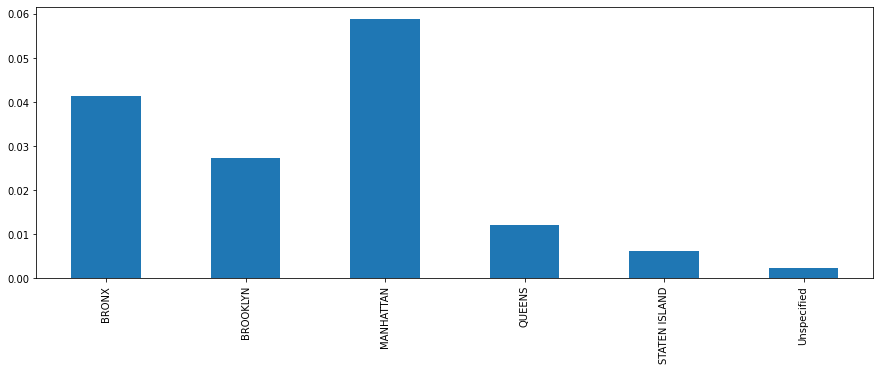

In [42]:
(noise_complaints_counts / complaints_counts).plot(kind='bar')